# Predicting daily electricity price prediction for future contracts in Germany and France

The aim is to model the electricity price from weather, energy (commodities) and commercial data for two European countries - France and Germany. 

More precisely, the goal is to learn a model that outputs from these explanatory variables a good estimation for the daily price variation of electricity futures contracts, in France and Germany. These contracts allow you to receive (or to deliver) a given amount of electricity at a specified price by the contract delivered at a specified time in the future (at the contract's maturity). Thus, futures contracts are financial instruments that give you some expected value on the future price of electricity under actual market conditions - here, we focus on short-term maturity contracts (24h). 

The variables consist of daily data for each country which involve weather quantitative measurements (temperature, rain, wind), energetic production (commodity price changes), and electricity use (consumption, exchanges between the two countries, import-export with the rest of Europe).

The score function (metric) used is the Spearman's correlation between the output and the actual daily price changes over the testing data set sample.

In [345]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression,Ridge,Lasso,RidgeCV, ElasticNet
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from itertools import combinations
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')



The input data X_train and X_test represent the same explanatory variables but over two different time periods.

The columns ID in X_train et Y_train are identical, and the same holds true for the testing data. 1494 rows are available for the training data sets while 654 observations are used for the test data sets.

Input data sets comprise 35 columns:

ID: Unique row identifier, associated with a day (DAY_ID) and a country (COUNTRY),
DAY_ID: Day identifier - dates have been anonymized, but all data corresponding to a specific day is consistent,
COUNTRY: Country identifier - DE = Germany, FR = France,
and then contains daily commodity price variations,

GAS_RET: European gas,
COAL_RET: European coal,
CARBON_RET: Carbon emissions futures,
weather measures (daily, in the country x),

x_TEMP: Temperature,
x_RAIN: Rainfall,
x_WIND: Wind,
energy production measures (daily, in the country x),

x_GAS: Natural gas,
x_COAL: Hard coal,
x_HYDRO: Hydro reservoir,
x_NUCLEAR: Daily nuclear production,
x_SOLAR: Photovoltaic,
x_WINDPOW: Wind power,
x_LIGNITE: Lignite,
and electricity use metrics (daily, in the country x),

x_CONSUMPTON: Total electricity consumption,
x_RESIDUAL_LOAD: Electricity consumption after using all renewable energies,
x_NET_IMPORT: Imported electricity from Europe,
x_NET_EXPORT: Exported electricity to Europe,
DE_FR_EXCHANGE: Total daily electricity exchange between Germany and France,
FR_DE_EXCHANGE: Total daily electricity exchange between France and Germany.
Output data sets are composed of two columns:

ID: Unique row identifier - corresponding to the input identifiers,
TARGET: Daily price variation for futures of 24H electricity baseload.


Lets begin by reading the input and output training files.

In [347]:
X_train = pd.read_csv('X_train_NHkHMNU.csv')
Y_train = pd.read_csv('y_train_ZAN5mwg.csv')

#Lets copy the values of the target variable to the X dataframe
X_train["TARGET"]=Y_train["TARGET"]

# Lets look at first five rows of the data frame
X_train.head()

,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,...,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET,TARGET
0,1054,206,FR,0.210099,-0.427458,-0.606523,0.606523,NaN,0.692860,NaN,...,-0.172680,-0.556356,-0.790823,-0.283160,-1.069070,-0.063404,0.339041,0.124552,-0.002445,0.028313
1,2049,501,FR,-0.022399,-1.003452,-0.022063,0.022063,-0.573520,-1.130838,0.573520,...,-1.240300,-0.770457,1.522331,0.828412,0.437419,1.831241,-0.659091,0.047114,-0.490365,-0.112516
2,1924,687,FR,1.395035,1.978665,1.021305,-1.021305,-0.622021,-1.682587,0.622021,...,-0.480700,-0.313338,0.431134,0.487608,0.684884,0.114836,0.535974,0.743338,0.204952,-0.180840
3,297,720,DE,-0.983324,-0.849198,-0.839586,0.839586,-0.270870,0.563230,0.270870,...,-1.114838,-0.507570,-0.499409,-0.236249,0.350938,-0.417514,0.911652,-0.296168,1.073948,-0.260356
4,1101,818,FR,0.143807,-0.617038,-0.924990,0.924990,NaN,0.990324,NaN,...,-0.541465,-0.424550,-1.088158,-1.011560,0.614338,0.729495,0.245109,1.526606,2.614378,-0.071733


The DE_FR_EXCHANGE and FR_DE_EXCHANGE seems to exactly correlated which makes sense.  Similarly the net export and net import columns are highly correlated which makes sense. One can look at their correlation matrix to confirm this. 

<Axes: >

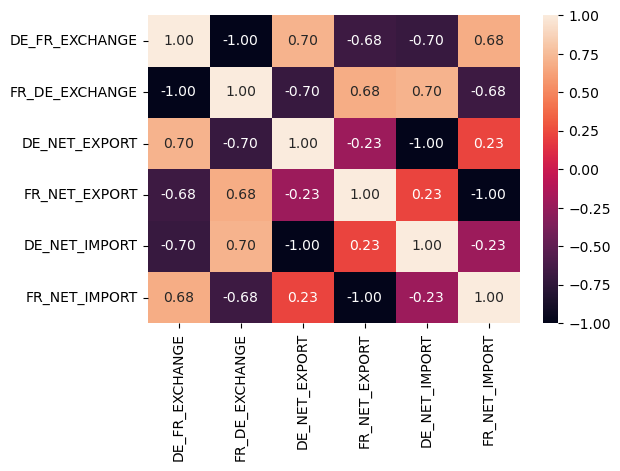

In [286]:
#corr_mat=X_train.drop(["ID","COUNTRY"],axis=1).corr()
corr_mat=X_train[["DE_FR_EXCHANGE","FR_DE_EXCHANGE","DE_NET_EXPORT","FR_NET_EXPORT","DE_NET_IMPORT","FR_NET_IMPORT"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_mat,annot=True,fmt=".2f")

One can see that they are indeed exactly correlated. Hence we can drop them.

In [349]:
drop_cols=["FR_DE_EXCHANGE","DE_NET_IMPORT","FR_NET_IMPORT"]
X_train.drop(drop_cols,inplace=True,axis=1) 



Lets do some plotting ! Lets look the distribution of the all the features.

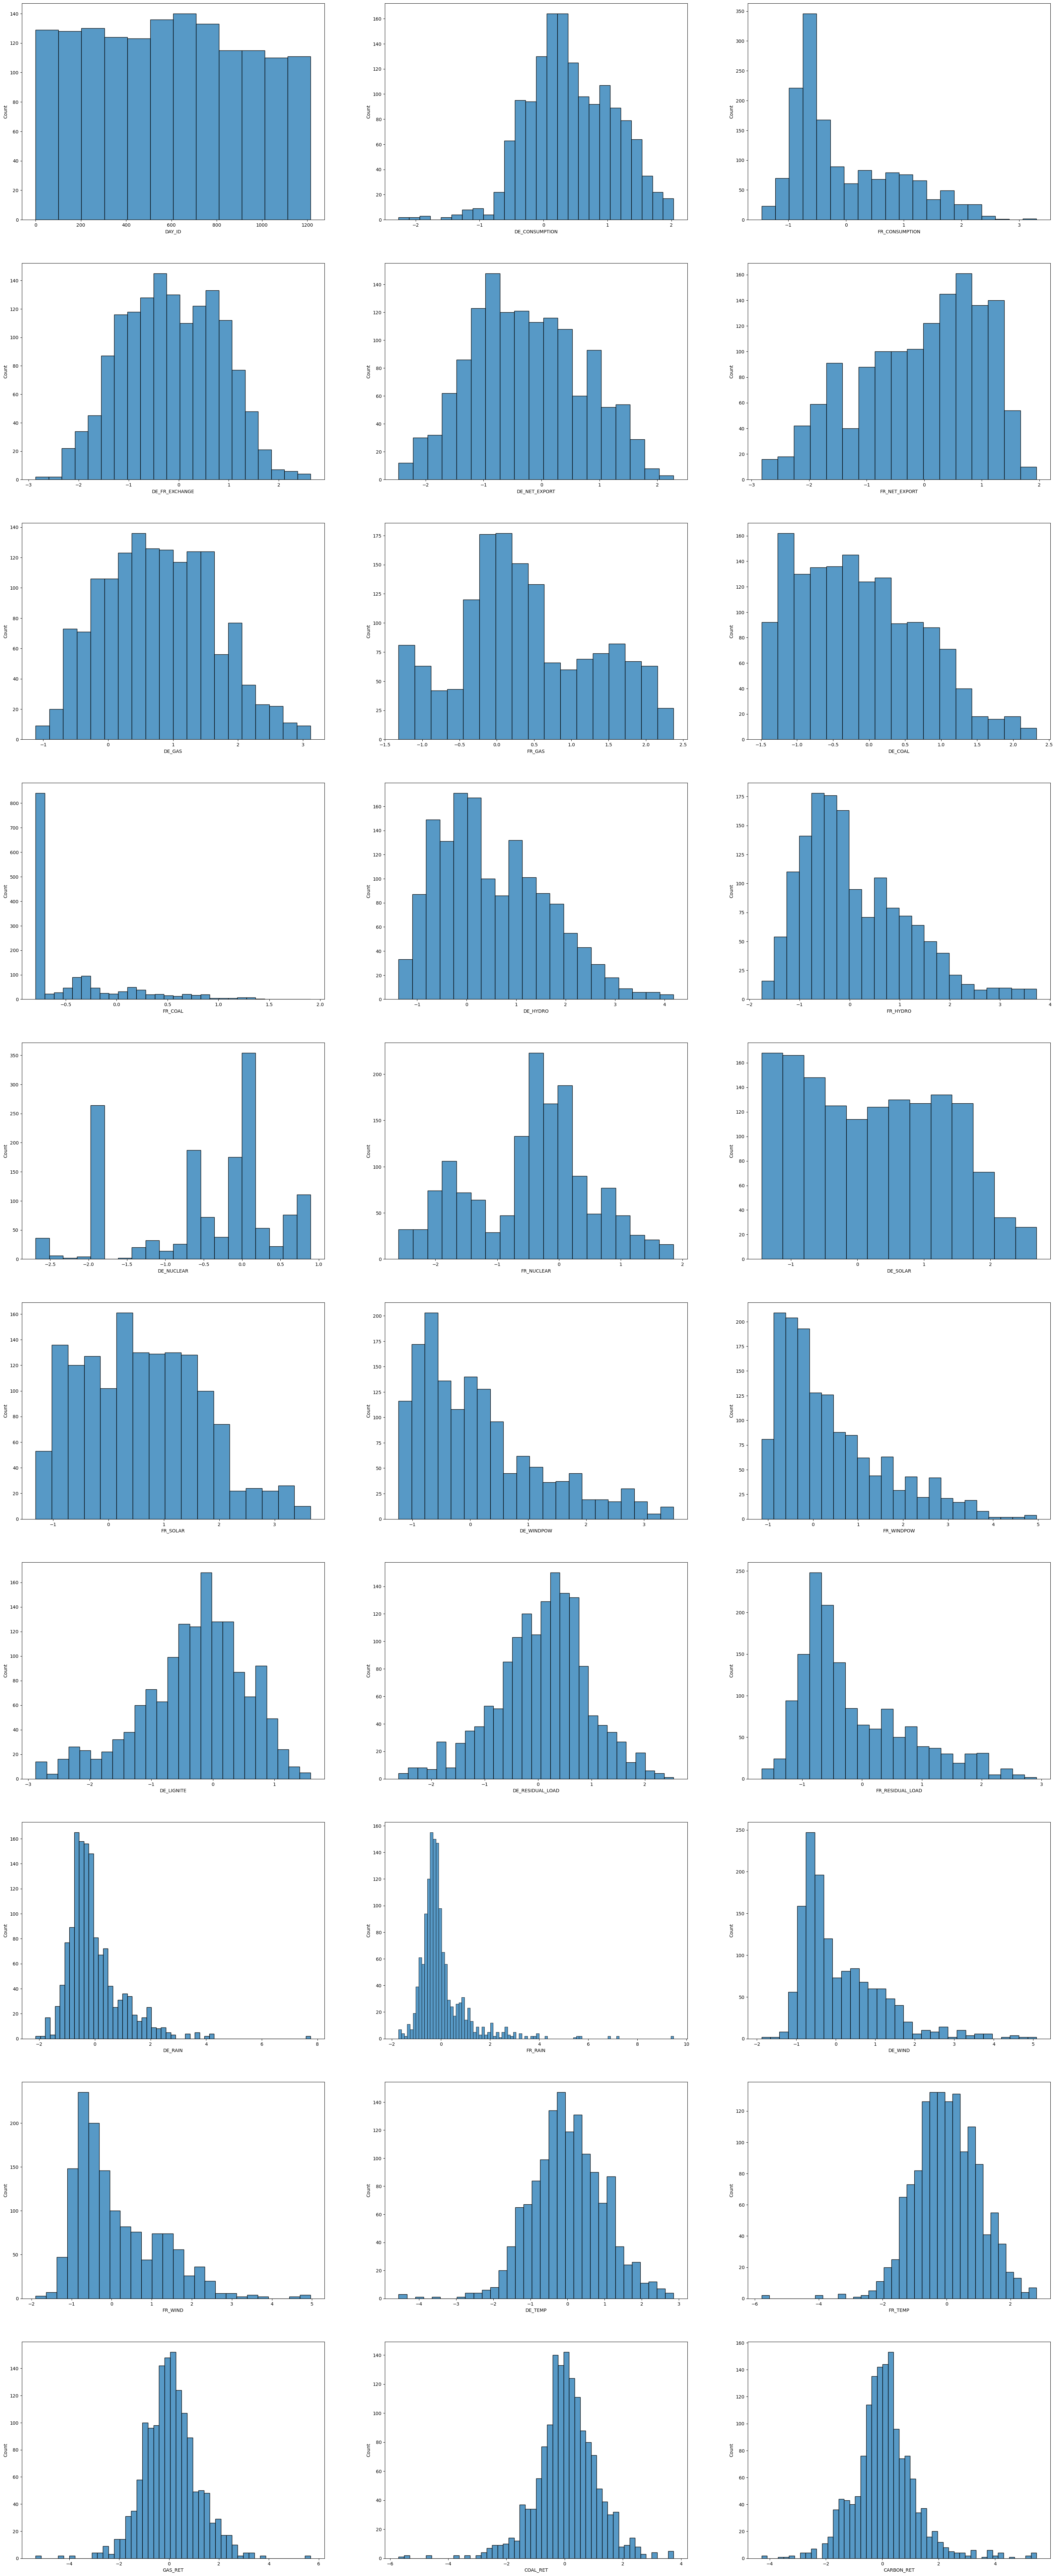

In [160]:
plt.figure(figsize=(40,100))

for i in range(len(cols)):
    plt.subplot(10,3,i+1)
    sns.histplot(x=cols[i],data=X_train.drop(["ID","COUNTRY"],axis=1))

Interesting ! The values of these features have been already scaled such that they have negative values. This doesnt make much sense for most of these quantities since they are usually positive and for feature interactions one needs positive values. Hence lets apply min max scalar to some of these features below. 

Also notice some of the variables are highly skewed.

In [351]:
cols_pos=['DE_CONSUMPTION', 'FR_CONSUMPTION', 'DE_GAS', 'FR_GAS', 'DE_COAL','DE_HYDRO', 'FR_HYDRO',  'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET','FR_COAL','DE_NUCLEAR']

for col in cols_pos:
    X_train[col]=(X_train[col]-min(X_train[col]))/(max(X_train[col])-min(X_train[col]))

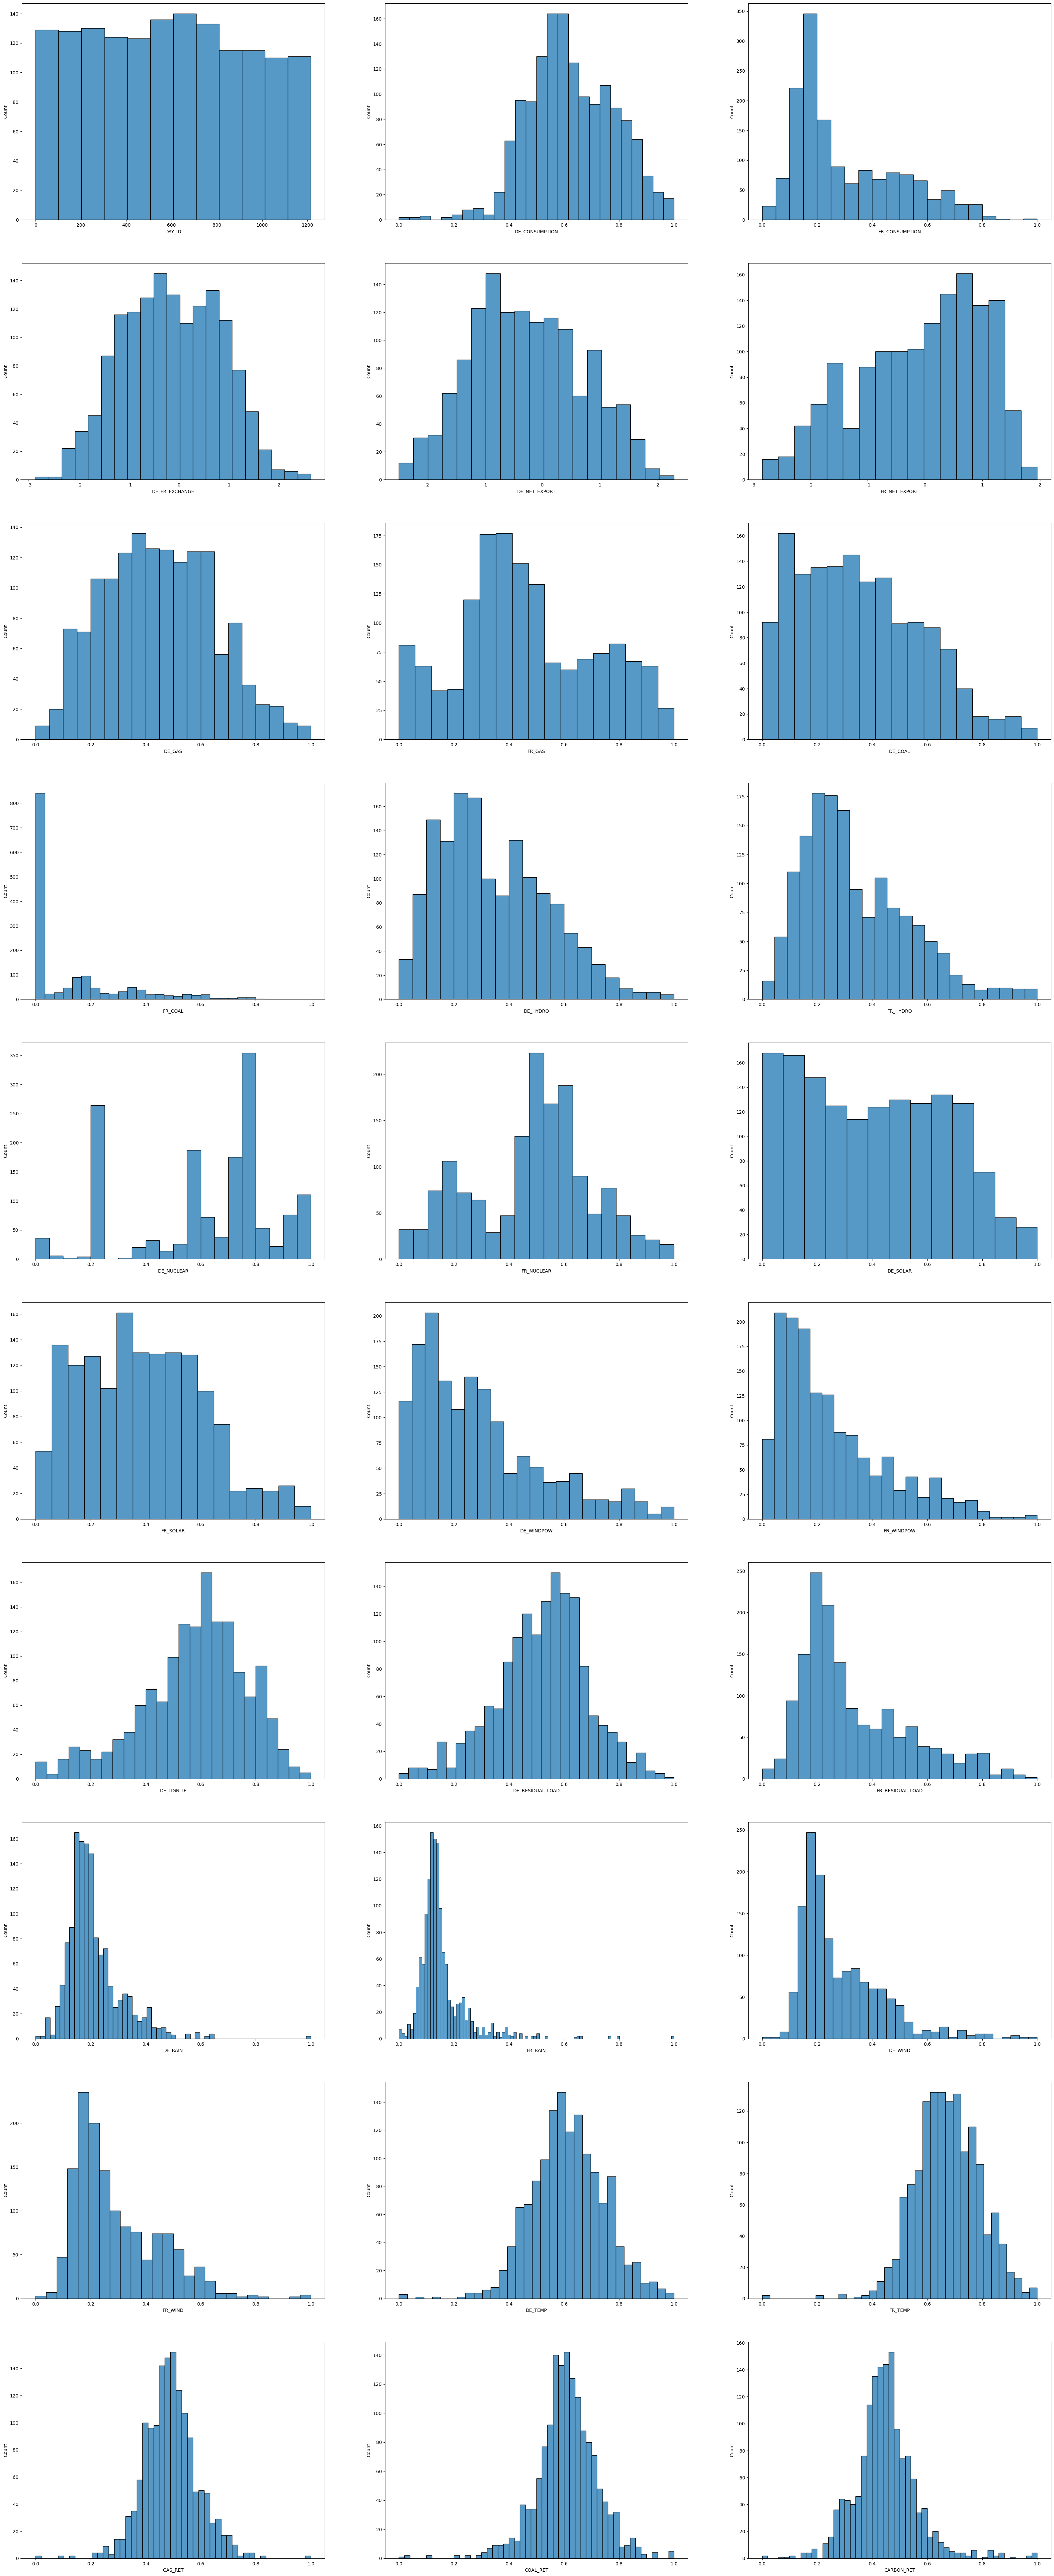

In [164]:
plt.figure(figsize=(40,100))

for i in range(len(cols)):
    plt.subplot(10,3,i+1)
    sns.histplot(x=cols[i],data=X_train.drop(["ID","COUNTRY"],axis=1))

Now lets plot these features versus daily price variations to see if we can find any patterns !

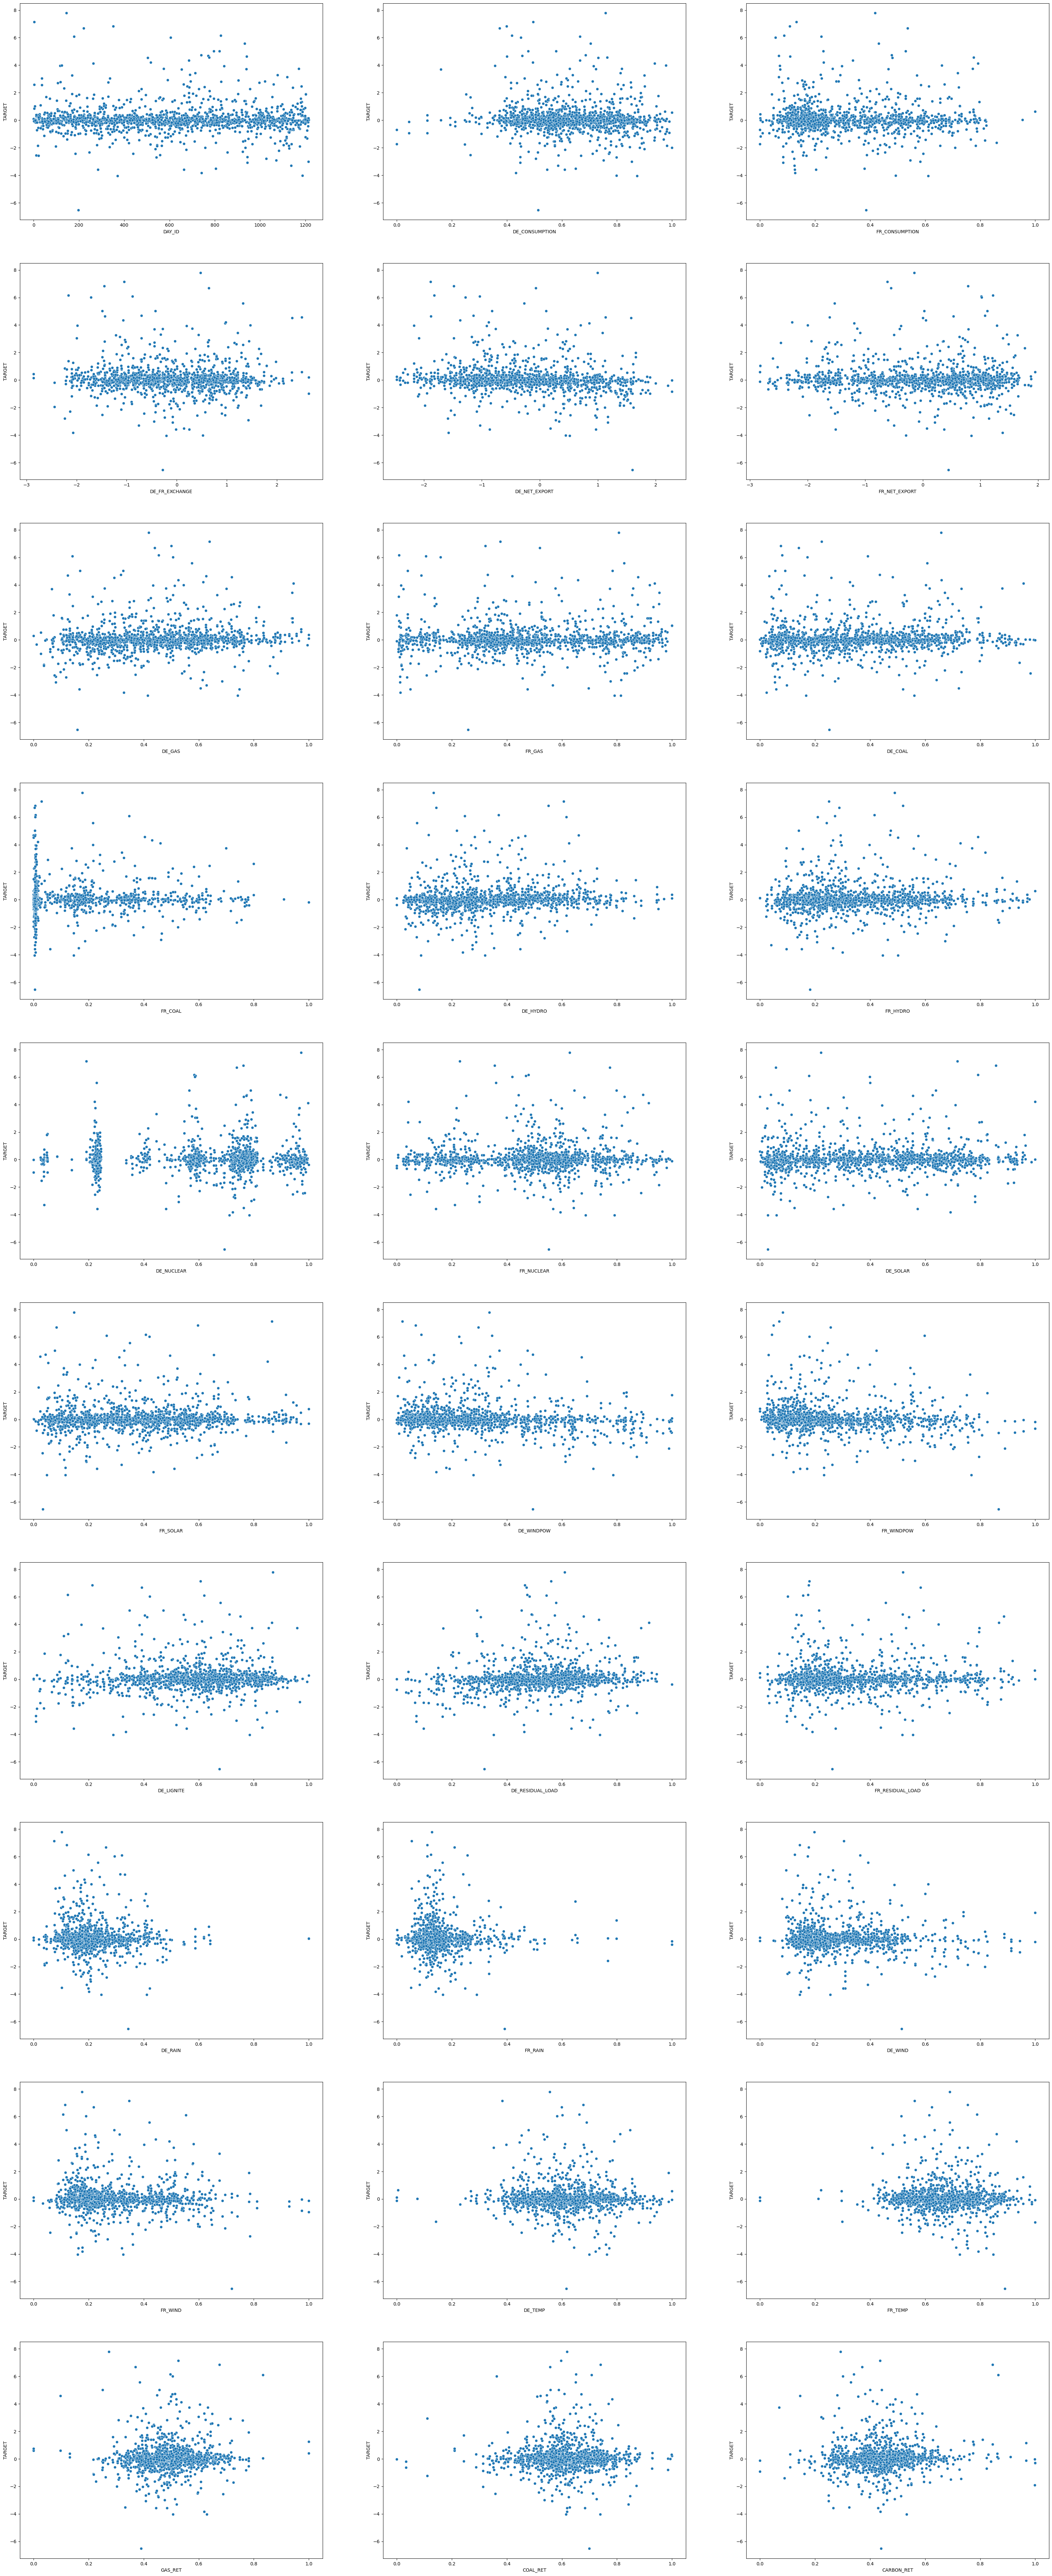

In [353]:
cols=X_train.drop(["ID","COUNTRY","TARGET"],axis=1).columns

plt.figure(figsize=(40,100))

for i in range(len(cols)):
    plt.subplot(10,3,i+1)
    sns.scatterplot(x=cols[i],y="TARGET",data=X_train)

Looking at the plots, the features do not seem very correlated with the TARGET. Might need to do some feature engineering if we are running a linear model. Or we could get try boosted decision trees to see if that performs better.  

In [262]:

for col in cols_pos+['TARGET']:
    
     
    q1=X_train[col].quantile(0.25)
    q3=X_train[col].quantile(0.75)
    
    iqr = q3-q1
    Lower_tail = q1 - 1.5 * iqr
    Upper_tail = q3 + 1.5 * iqr

    med=np.median(X_train[col])
    
    for i in X_train[col]:
        if i > Upper_tail or i < Lower_tail:
                X_train[col] = X_train[col].replace(i, med)

Let's see if there are any missing values and if so we will drop them for now. 

In [356]:
np.sum(X_train.isna())

ID                    0
DAY_ID                0
COUNTRY               0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
DE_FR_EXCHANGE       25
DE_NET_EXPORT       124
FR_NET_EXPORT        70
DE_GAS                0
FR_GAS                0
DE_COAL               0
FR_COAL               0
DE_HYDRO              0
FR_HYDRO              0
DE_NUCLEAR            0
FR_NUCLEAR            0
DE_SOLAR              0
FR_SOLAR              0
DE_WINDPOW            0
FR_WINDPOW            0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN              94
FR_RAIN              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
FR_TEMP              94
GAS_RET               0
COAL_RET              0
CARBON_RET            0
TARGET                0
dtype: int64

In [95]:
for col in X_train.columns:
    if col not in ["ID","DAY_ID","COUNTRY"]:
        X_train[col]=X_train[col].fillna(X_train[col].median())
       # X_train.loc[X_train["COUNTRY"]=="FR",col]=X_train.loc[X_train["COUNTRY"]=="FR",col].fillna(X_train.loc[X_train["COUNTRY"]=="FR",col].median())

There seem to be a few columns where there are missing values. We can either fill them with the median values for each column or drop the rows entirely. We will drop them here. 

In [358]:
X_train.dropna(inplace=True)
X_train.head()

,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_GAS,FR_GAS,...,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET,TARGET
1,2049,501,FR,0.521737,0.096347,-0.022063,-0.573520,-1.130838,0.305060,0.472718,...,0.089860,0.085357,0.488477,0.397025,0.673163,0.885407,0.425460,0.608648,0.388720,-0.112516
2,1924,687,FR,0.851418,0.722449,1.021305,-0.622021,-1.682587,0.819101,0.932159,...,0.166706,0.126172,0.331832,0.347348,0.706566,0.685925,0.533863,0.682299,0.460008,-0.180840
3,297,720,DE,0.298236,0.128733,-0.839586,-0.270870,0.563230,0.378973,0.409768,...,0.102552,0.108830,0.198249,0.241835,0.661489,0.624055,0.567941,0.572333,0.549103,-0.260356
5,1520,467,FR,0.458264,0.146385,-0.717490,-1.117139,-0.200305,0.625889,0.440056,...,0.117962,0.136842,0.144820,0.142571,0.627894,0.727518,0.566072,0.694789,0.554282,0.932105
6,1546,144,FR,0.472296,0.164868,0.399588,0.183998,-0.986235,0.457051,0.375697,...,0.047562,0.106845,0.224159,0.098327,0.544875,0.689722,0.656662,0.656369,0.508892,0.192680


## ElasticNet model

Ok now that we have a clean data set, lets try to train a model. We will use ElasticNet regularization for our model and see if it performs better than plain linear regression with a benchmark score of 0.15. To do that we will use a GridSearch to find the optimal parameters with the best spearman correlation. Before we do that, lets scale our inputs using Robust Scaler to minimize the effect of outliers. 

In [362]:
from sklearn.preprocessing import RobustScaler,MinMaxScaler
from sklearn.decomposition import PCA

X_scaled=RobustScaler().fit_transform(X_train.drop(['ID','DAY_ID','COUNTRY','TARGET'],axis=1))
Y=X_train[['TARGET']]

Now lets split the data into train and test sets. We will use a test size of 0.3 

In [296]:
X_train1,X_test1,Y_train1,Y_test1= train_test_split(X_scaled,Y,test_size=0.3,random_state=42)

We define a function to determine the spearman correlation between the predicted data and the test data. We run the grid search using this function and search for parameters that optimize the spearman score. 

In [298]:
def spearman_scorer(y_true, y_pred):
    correlation, _ = spearmanr(y_true, y_pred)
    return correlation


# Use GridSearchCV instead of RidgeCV
param_grid = {'alpha': np.logspace(-3, 0, 40),'l1_ratio' : np.logspace(-3, 0, 40) }
scores={}

for alpha in param_grid['alpha']:
    for l1_ratio in param_grid['l1_ratio']:

        model=ElasticNet(alpha=alpha,l1_ratio=l1_ratio)
        model.fit(X_train1,Y_train1)
        y_pred=model.predict(X_test1)
        scores[spearman_scorer(Y_test1,y_pred)]=(alpha,l1_ratio)


(max(scores.keys()),scores[max(scores.keys())])

(0.18704133344296017, (0.05878016072274915, 0.0014251026703029977))

Next, we process the test set the same way as we did on the train set and predict using our model, while saving the predictions to a csv file. We fill the missing values in the test data with median values.


In [375]:
X_test = pd.read_csv('X_test_final.csv')
#Y_test_submission = X_test[['ID']].copy()
X_test.drop(drop_cols,inplace=True,axis=1)

for col in cols_pos:
    X_test[col]=(X_test[col]-min(X_test[col]))/(max(X_test[col])-min(X_test[col]))

X_t=X_test.drop(["ID","DAY_ID","COUNTRY"],axis=1)

for col in X_t.columns:
    X_t[col]=X_t[col].fillna(X_t[col].median())


X_t.head()

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_GAS,FR_GAS,DE_COAL,FR_COAL,DE_HYDRO,...,FR_RESIDUAL_LOAD,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
0,0.837197,0.561133,-0.423521,0.165333,0.519419,0.631089,0.483957,0.940367,0.539511,0.442661,...,0.578533,0.186494,0.137736,0.040635,0.105831,0.684808,0.604519,0.513380,0.518482,0.355660
1,0.887075,0.724991,0.601610,0.342802,0.555367,0.534885,0.867113,0.401934,0.001202,0.579648,...,0.744947,0.209374,0.128942,0.066912,0.035928,0.473459,0.331617,0.470959,0.615253,0.542170
2,0.886249,0.717101,1.179158,1.620928,0.666901,0.339477,0.354574,0.160241,0.004151,0.379441,...,0.681822,0.360116,0.124054,0.200921,0.185558,0.682640,0.495307,0.239380,0.481822,0.423495
3,0.819154,0.522015,-0.044539,-0.235460,-0.205276,0.531121,0.318333,0.612022,0.216570,0.635452,...,0.526346,0.182593,0.150203,0.063219,0.102247,0.594269,0.559704,0.337881,0.801670,0.539592
4,0.902854,0.676377,0.617391,0.608561,-0.240856,0.600150,0.758185,0.826399,0.235262,0.449530,...,0.690387,0.223997,0.106180,0.068662,0.041029,0.585432,0.532046,0.141519,0.459237,0.407272


In [ ]:
alpha, l1_ratio = (0.05541020330009492, 0.001)
model=ElasticNet(alpha=alpha,l1_ratio=l1_ratio)
model.fit(X_scaled,Y)
y_pred=model.predict(RobustScaler().fit_transform(X_t))

predictions=pd.DataFrame({'ID':X_test['ID'],'TARGET':y_pred})
print(predictions.head())
predictions.to_csv("predictions_new.csv",index=False)

We find that this model gives a spearman score of 0.18 with the test data which is 20% better than the benchmark model. 

## Light gradient boosting 

We will now try to see if light gradient boosting gives a better prediction than the linear regularized model. We will use again use a Grid search CV to look for the optimal parameters for our model.  

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.linear_model import ElasticNet
import xgboost as xgb
import lightgbm as lgb

def spearman_scorer(y_true, y_pred):
    """Spearman correlation as a scoring function"""
    correlation, _ = spearmanr(y_true, y_pred)
    return correlation

# Create scorer object
spearman_score = make_scorer(spearman_scorer, greater_is_better=True)


param_grid = {
    'max_depth': [4,5,6],
    'learning_rate': [0.01, 0.005,0.02],
    'n_estimators': [100,200],
    'num_leaves': [5, 10, 13],            # key LGBM param — controls tree complexity
    'reg_lambda': [4,6,8,10],           # L2
 #   'reg_alpha': [0],        # L1 (LGBM exposes both easily)
    'subsample': [0.1,0.3,0.7, 0.9],
    'colsample_bytree': [0.1,0.3,0.7, 0.9],
}

model=lgb.LGBMRegressor(random_state=42,verbose=-1,min_child_samples=20)


grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring=spearman_score,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

grid_search.fit(X_scaled, Y.values.ravel())

print(f"Best alpha: {grid_search.best_params_}")
print(f"Best Spearman correlation: {grid_search.best_score_:.4f}")

In [ ]:
model= lgb.LGBMRegressor(subsample= 0.7, reg_lambda= 6, num_leaves= 5, n_estimators= 100, max_depth= 6, learning_rate= 0.02, colsample_bytree= 0.3, random_state=42,
    verbose=-1)

model.fit(X_scaled,Y)
y_pred=model.predict(X_t)

predictions=pd.DataFrame({'ID':X_test['ID'],'TARGET':y_pred})
print(predictions.head())
predictions.to_csv("predictions_new.csv",index=False)

We find that this model gives a spearman score worse than the benchmark model.

In [51]:
def signed_log(x):
    return np.log(x + 1)

X_train[cols]=signed_sqrt(X_train[cols].values)

In [96]:
def calculate_feature_correlation(X, y, feature_name):
    """Calculate Spearman correlation for a single feature"""
    return abs(spearmanr(X[feature_name], y)[0])

def create_ratio_features(df, feature_list):
    """Create ratio features between all pairs"""
    new_features = {}
    
    for i, feat1 in enumerate(feature_list):
        for feat2 in feature_list[i+1:]:
            # Ratio features
            ratio_name = f"{feat1}_DIV_{feat2}"
            new_features[ratio_name] = df[feat1] / (df[feat2] + 1e-2)

    return pd.DataFrame(new_features, index=df.index)
    

def create_product_features(df, feature_list,max_order=2):   

    new_features = {}
    
    # Pairwise products
    for feat1, feat2 in combinations(feature_list, 2):
        prod_name = f"{feat1}_TIMES_{feat2}"
        new_features[prod_name] = df[feat1] * df[feat2]
    
    # Triple products if max_order >= 3
    if max_order >= 3:
        for feat1, feat2, feat3 in combinations(feature_list, 3):
            prod_name = f"{feat1}_X_{feat2}_X_{feat3}"
            new_features[prod_name] = df[feat1] * df[feat2] * df[feat3]
    
    return pd.DataFrame(new_features, index=df.index)

def create_polynomial_features(df, feature_list, degree=2):
    """Create polynomial features (squares, cubes, etc.)"""
    poly_features = {}
    
    for feat in feature_list:
        for d in range(2, degree + 1):
            poly_name = f"{feat}_POW{d}"
            poly_features[poly_name] = df[feat] ** d
    
    return pd.DataFrame(poly_features, index=df.index)

def create_log_features(df, feature_list):
    """Create log-transformed features for positive values"""
    log_features = {}
    
    for feat in feature_list:
        # Log of absolute value + 1 to handle negatives and zeros
        log_name = f"LOG_{feat}"
        log_features[log_name] = np.log(np.abs(df[feat]) + 1)
        
        # Sign-preserving log
        sign_log_name = f"SIGNLOG_{feat}"
        log_features[sign_log_name] = np.sign(df[feat]) * np.log(np.abs(df[feat]) + 1)
    
    return pd.DataFrame(log_features, index=df.index)

def create_sqrt_features(df, feature_list):
    """Create square root features"""
    sqrt_features = {}
    
    for feat in feature_list:
        # Sqrt of absolute value
        sqrt_name = f"SQRT_{feat}"
        sqrt_features[sqrt_name] = np.sqrt(np.abs(df[feat]))
        
        # Sign-preserving sqrt
        sign_sqrt_name = f"SIGNSQRT_{feat}"
        sqrt_features[sign_sqrt_name] = np.sign(df[feat]) * np.sqrt(np.abs(df[feat]))
    
    return pd.DataFrame(sqrt_features, index=df.index)


    
    

def advanced_feature_engineering(df, y):
    """
    Comprehensive feature engineering with systematic exploration
    """


    df_new = df.copy()
    
    base_features = [col for col in df_new.columns if col not in ['ID', 'COUNTRY', 'TARGET']]
    
    print(f"\n2. Base features: {len(base_features)}")
    
    # Start with base features
    df_features = df_new[base_features].copy()
    
    
    # Create polynomial features from top features
    print(f"\n4. Creating polynomial features (degree 2-3)...")
    poly_df = create_polynomial_features(df_new, base_features, degree=2)
    print(f"   Created {len(poly_df.columns)} polynomial features")
    
    # Create product/interaction features
    print(f"\n5. Creating interaction features (products)...")
    product_df = create_product_features(df_new, base_features, max_order=2)
    print(f"   Created {len(product_df.columns)} product features")
    
    # Create ratio features
    print(f"\n6. Creating ratio features...")
    ratio_df = create_ratio_features(df_new, base_features)
    print(f"   Created {len(ratio_df.columns)} ratio features")
    

    # Combine all features
    all_new_features = pd.concat([poly_df, product_df], axis=1)
   # , log_df, sqrt_df
    
    # Remove NaN and inf values
    all_new_features = all_new_features.replace([np.inf, -np.inf], np.nan)
    all_new_features = all_new_features.fillna(0)
    
    print(f"\n9. Total engineered features: {len(all_new_features.columns)}")
    
    # Quick correlation screening - keep features with |correlation| > 0.05
   # print(f"\n10. Screening features by correlation threshold...")
    good_features = []
    for col in all_new_features.columns:
        corr = abs(spearmanr(all_new_features[col], y)[0])
       
        if corr > 0.1:  # Keep features with at least 0.05 correlation
            good_features.append(col)
            
    print(f"  Kept {len(good_features)} features with |correlation| > 0.05")
    
    # Combine base features with screened engineered features
    df_combined = pd.concat([ df_features, all_new_features[good_features]], axis=1)
    
    
    return df_combined






In [97]:
df=X_train.copy()

X = advanced_feature_engineering(df, df["TARGET"])
X=X.loc[:, ~X.columns.duplicated()]
#X_de = df_de_features.drop([ 'COUNTRY'], axis=1)
y = df['TARGET']


2. Base features: 29

4. Creating polynomial features (degree 2-3)...
   Created 29 polynomial features

5. Creating interaction features (products)...
   Created 406 product features

6. Creating ratio features...
   Created 406 ratio features

9. Total engineered features: 435
  Kept 41 features with |correlation| > 0.05


In [77]:
X_de = advanced_feature_engineering(df_de, 'DE', df_de["TARGET"])
X_de=X_de.loc[:, ~X_de.columns.duplicated()]
#X_de = df_de_features.drop([ 'COUNTRY'], axis=1)
y_de = df_de['TARGET']

X_fr = advanced_feature_engineering(df_fr, 'FR', df_fr["TARGET"])
X_fr=X_fr.loc[:, ~X_fr.columns.duplicated()]
#X_fr = df_fr_features.drop([ 'COUNTRY'], axis=1)
y_fr = df_fr['TARGET']


    


Advanced Feature Engineering for DE

2. Base features: 29

4. Creating polynomial features (degree 2-3)...
   Created 29 polynomial features

5. Creating interaction features (products)...
   Created 406 product features

6. Creating ratio features...
   Created 406 ratio features

9. Total engineered features: 435
  Kept 118 features with |correlation| > 0.05

Advanced Feature Engineering for FR

2. Base features: 29

4. Creating polynomial features (degree 2-3)...
   Created 29 polynomial features

5. Creating interaction features (products)...
   Created 406 product features

6. Creating ratio features...
   Created 406 ratio features

9. Total engineered features: 435
  Kept 114 features with |correlation| > 0.05


In [9]:
X_train.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET',
       'prices'],
      dtype='object')

In [210]:
    

def advanced_feature_engineering_test(df):
    """
    Comprehensive feature engineering with systematic exploration
    """
 

    df_new = df.copy()
    
    base_features = [col for col in df_new.columns if col not in ['COUNTRY',"ID"]]
    
    print(f"\n2. Base features: {len(base_features)}")
    
    # Start with base features
    df_features = df_new[base_features].copy()
  #  df_features["ID"]=df_new["ID"]
    
    # Create polynomial features from top features
    print(f"\n4. Creating polynomial features (degree 2-3)...")
    poly_df = create_polynomial_features(df_new, base_features, degree=2)
    print(f"   Created {len(poly_df.columns)} polynomial features")
    
    # Create product/interaction features
    print(f"\n5. Creating interaction features (products)...")
    product_df = create_product_features(df_new, base_features, max_order=2)
    print(f"   Created {len(product_df.columns)} product features")
    

    # Combine all features
    all_new_features = pd.concat([poly_df, product_df], axis=1)
   # , log_df, sqrt_df
    
    # Remove NaN and inf values
    all_new_features = all_new_features.replace([np.inf, -np.inf], np.nan)
    all_new_features = all_new_features.fillna(0)
    
    # Combine base features with screened engineered features
    df_combined = pd.concat([df_features, all_new_features], axis=1)
    
    
    return df_combined






In [211]:
#X_test=pd.read_csv("/kaggle/input/testset/X_test_final.csv")

df1 = X_test.copy()

df1_features = advanced_feature_engineering_test(df1)

X_test_new = df1_features[X.columns]
X_test_scaled=RobustScaler().fit_transform(X_test_new)
y_pred=model.predict(X_test_scaled)

# Split by country
#df1_de = df1[df1['COUNTRY'] == 'DE'].copy()
#df1_fr = df1[df1['COUNTRY'] == 'FR'].copy()

#df1_de_features = advanced_feature_engineering_test(df1_de, 'DE')
#df1_de_features=df1_de_features.loc[:, ~df1_de_features.columns.duplicated()]
#X_test_de = df1_de_features[X_de.columns]

#df1_fr_features = advanced_feature_engineering_test(df1_fr, 'FR')
#df1_fe_features=df1_fr_features.loc[:, ~df1_fr_features.columns.duplicated()]
#X_test_fr = df1_fr_features[X_fr.columns]

#Xt_scaled_de=RobustScaler().fit_transform(X_test_de)
#Xt_scaled_fr=RobustScaler().fit_transform(X_test_fr)

#y_pred_de=model_de.predict(Xt_scaled_de)
#y_pred_fr=model_fr.predict(Xt_scaled_fr)

#predictions=pd.concat([pd.DataFrame({'ID':df1_fr['ID'],'TARGET':y_pred_fr}),pd.DataFrame({'ID':df1_de['ID'],'TARGET':y_pred_de})])

predictions=pd.DataFrame({'ID':df1['ID'],'TARGET':y_pred})
print(predictions.head())
predictions.to_csv("predictions_new.csv",index=False)




2. Base features: 29

4. Creating polynomial features (degree 2-3)...
   Created 29 polynomial features

5. Creating interaction features (products)...
   Created 406 product features
     ID    TARGET
0  1115  0.148311
1  1202  0.118029
2  1194 -0.192643
3  1084  0.189404
4  1135  0.111551
